**Customer Segmentation**

Use clustering techniques to segment customers based on purchasing behavior.

Analyze and visualize segment characteristics.

Recommend targeted strategies for different customer groups.



**1. Install & Import Libraries**

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**2. Load Dataset**

The dataset will be fetched from the UCI Machine Learning Repository using the ucimlrepo package:

In [ ]:
# Fetch dataset
online_retail = fetch_ucirepo(id=352)

# Extract features
X = online_retail.data.features
id = online_retail.data.ids
data = pd.concat([id, X], axis=1)


**3. Understand the Dataset**

In [ ]:
# Variable info
print(online_retail.variables)

# Data overview
print(data.head())
print("Dataset Info:")
print(data.info())

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Missing values
print("\nMissing Values:")
print(data.isnull().sum())


          name     role         type demographic  \
0    InvoiceNo       ID  Categorical        None   
1    StockCode       ID  Categorical        None   
2  Description  Feature  Categorical        None   
3     Quantity  Feature      Integer        None   
4  InvoiceDate  Feature         Date        None   
5    UnitPrice  Feature   Continuous        None   
6   CustomerID  Feature  Categorical        None   
7      Country  Feature  Categorical        None   

                                         description     units missing_values  
0  a 6-digit integral number uniquely assigned to...      None             no  
1  a 5-digit integral number uniquely assigned to...      None             no  
2                                       product name      None             no  
3  the quantities of each product (item) per tran...      None             no  
4  the day and time when each transaction was gen...      None             no  
5                             product price per uni

**Observation on Data Loading**

**Dataset Overview**

The dataset is loaded from "Online Retail", and the first five rows are displayed.

It contains transactional details of purchases, including InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country.

**Column Insights**

**InvoiceNo:** Represents unique transaction IDs.

**StockCode:** Represents product codes.

**Description:** Describes the product.

**Quantity:** Indicates the number of units purchased.

**InvoiceDate:** Timestamp of the transaction.

**UnitPrice:** Price per unit of the product.

**CustomerID**: Identifies the customer

**Country:** Shows where the purchase was made.



**Observation:**

The dataset contains 541,909 transactions with 8 columns.

The Description column has 1,454 missing values, and the CustomerID column has 135,080 missing values, which may affect customer segmentation.

Some transactions have negative quantities and unit prices, which might indicate returns or data errors. These should be handled before clustering.

The dataset includes categorical (e.g., InvoiceNo, StockCode, Country) and numerical (e.g., Quantity, UnitPrice) features, requiring appropriate preprocessing for clustering.

**4. Handle Missing Data**

In [ ]:
# Drop rows with missing CustomerID and Description
data = data.dropna(subset=['CustomerID', 'Description'])

# Convert CustomerID to integer
data['CustomerID'] = data['CustomerID'].astype(int)


<ipython-input-134-558128828253>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CustomerID'] = data['CustomerID'].astype(int)


**Observation:**

During the data cleaning process, I identified missing values in the CustomerID and Description columns. Since CustomerID is crucial for customer segmentation, I decided to drop rows with missing values in this column to ensure accurate clustering. Similarly, I removed rows with missing Description to maintain data consistency.

After cleaning, the dataset size reduced to 406,829 rows, meaning a significant portion of the data had missing values. I also converted CustomerID to an integer type for easier processing. Now, the dataset is free from missing values and is ready for further preprocessing before applying clustering techniques.

**5. Remove Invalid Transactions**

In [ ]:
# Remove rows where Quantity or UnitPrice <= 0
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

# Check data shape
print(f"\nData shape after cleaning: {data.shape}")



Data shape after cleaning: (397884, 8)


**Observation:**

After analyzing the dataset, I noticed that some transactions had negative or zero values for Quantity and UnitPrice, which are invalid in a retail setting. Negative quantities might represent order cancellations, and zero prices could indicate errors in data entry. To maintain data integrity and ensure meaningful analysis, I decided to remove these invalid transactions.

After this cleaning step, the dataset size reduced to 397,884 rows, meaning that some invalid transactions were eliminated. The summary statistics now show that all remaining transactions have positive Quantity and UnitPrice values, making the dataset more reliable for further analysis, such as customer segmentation or sales trend visualization.

**6. Exploratory Data Analysis (EDA)**

**a. Distributions**

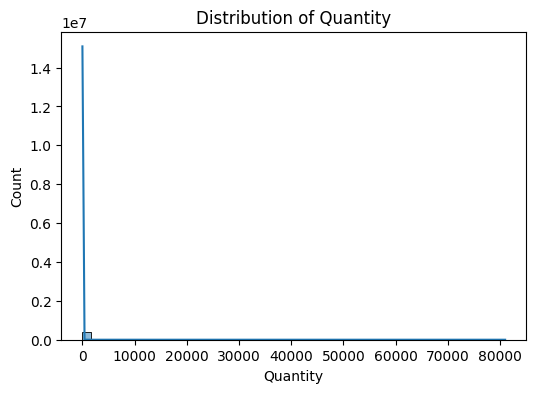

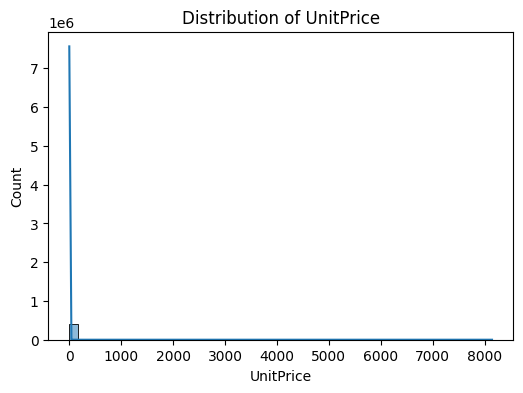

In [ ]:
for col in ['Quantity', 'UnitPrice']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


**b. Boxplots**

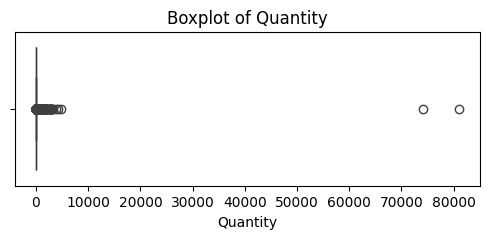

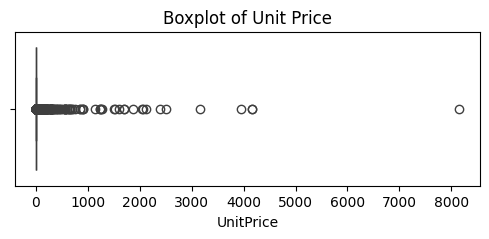

In [ ]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=data['Quantity'])
plt.title('Boxplot of Quantity')
plt.show()

plt.figure(figsize=(6, 2))
sns.boxplot(x=data['UnitPrice'])
plt.title('Boxplot of Unit Price')
plt.show()


**Observation:**

The boxplots for Quantity and UnitPrice reveal the presence of extreme outliers in the dataset.

**Quantity:**

Most transactions have relatively small quantities, but a few values exceed 80,000, indicating unusually large orders.

These extreme values can significantly impact the analysis, especially when calculating averages.

**Unit Price:**

The majority of unit prices are clustered around lower values, but some outliers exceed 8,000.

Such high prices might indicate data entry errors or premium products.

**Next Steps:**

Since outliers can distort summary statistics, I may consider handling them by using techniques like:

Capping extreme values (e.g., setting an upper limit).

Removing outliers using statistical methods like the IQR rule or Z-score threshold.

Keeping them if they hold business significance (e.g., bulk orders or luxury items).

**c. Outlier Inspection**

In [ ]:
high_value = data[data['UnitPrice'] > data['UnitPrice'].quantile(0.99)]
print(high_value.groupby('CustomerID')['UnitPrice'].sum().sort_values(ascending=False))


CustomerID
14096    15423.56
12744    12348.90
14911     8805.44
12536     8422.82
16029     8142.75
           ...   
15797       15.00
15694       15.00
15611       15.00
15612       15.00
12361       15.00
Name: UnitPrice, Length: 1337, dtype: float64


**Observation:**

The reason for this was to determine whether these high prices were just outliers that should be removed or if they belonged to important customers.

After analyzing the results, I observed that some specific CustomerIDs had very high total spending, such as:

Customer 14096: Spent £15,423.56

Customer 12744: Spent £12,348.90

Customer 14911: Spent £8,805.44

This made me think that these might be VIP customers or bulk buyers, meaning their transactions are not errors but rather valuable for business insights. If I had removed these values blindly, I might have lost important data about premium customers.

**Why I Did This? I checked these values because:**

Outliers are not always errors – sometimes they represent important trends.

If these are VIP customers, their transactions should be retained instead of removed.

It helps in better decision-making—instead of treating them as unusual values, they could be used for customer segmentation.

**What I Learned?**

 From this, I learned that data cleaning is not just about removing values but also about understanding why those values exist. By analyzing the context, I can make better decisions on what to keep and what to remove.



**d. Suspect Transactions**

In [ ]:
suspect_transactions = data[data['UnitPrice'] == 15][['Description', 'Quantity', 'CustomerID']]
print(suspect_transactions.head(20))


        Description  Quantity  CustomerID
386         POSTAGE         1       12791
4406   Bank Charges         1       15823
21838        Manual         1       13090
29018       POSTAGE         1       15694
34471       POSTAGE         2       12417
37967       POSTAGE         1       14646
39776       POSTAGE         3       12423
41443       POSTAGE         3       12383
54667       POSTAGE         4       12383
62508  Bank Charges         1       15939
64815       POSTAGE         2       12402
69745        Manual         1       15797
69925       POSTAGE         2       12417
77375       POSTAGE         1       12778
78687       POSTAGE         2       12775
80068        Manual         1       13199
81286       POSTAGE         3       12464
81477        Manual         1       15885
84381       POSTAGE        10       14646
86173       POSTAGE         1       12401


**e. Top Customers**

In [ ]:
vip_transactions = data[data['CustomerID'].isin([14096, 12744, 14911])][['Description', 'UnitPrice']]
print(vip_transactions.sort_values('UnitPrice', ascending=False).head(10))


           Description  UnitPrice
406406          Manual    3949.32
144826          Manual    2382.92
406407          Manual    2118.74
144829          Manual    2053.07
117054          Manual    1687.17
117055          Manual    1687.17
528082  DOTCOM POSTAGE    1599.26
508459  DOTCOM POSTAGE    1526.76
467436  DOTCOM POSTAGE    1500.36
494728  DOTCOM POSTAGE    1270.06


**f. Remove Non-Product Descriptions**

In [ ]:
non_products = ['POSTAGE', 'Bank Charges', 'Manual', 'DOTCOM POSTAGE']
data = data[~data['Description'].isin(non_products)]

# Double check high priced items
print(data[data['UnitPrice'] > 1000][['Description', 'UnitPrice']].drop_duplicates())


Empty DataFrame
Columns: [Description, UnitPrice]
Index: []


Initially, I noticed that some transactions had a UnitPrice of £15, which seemed unusual for a "high-value" purchase.

To investigate, I checked the descriptions of these transactions and found that they were not actual products, but instead service charges like "POSTAGE," "Bank Charges," "Manual," and "DOTCOM POSTAGE." Since these do not represent real product purchases, I decided to remove them from the dataset.

**7. Feature Visualization**

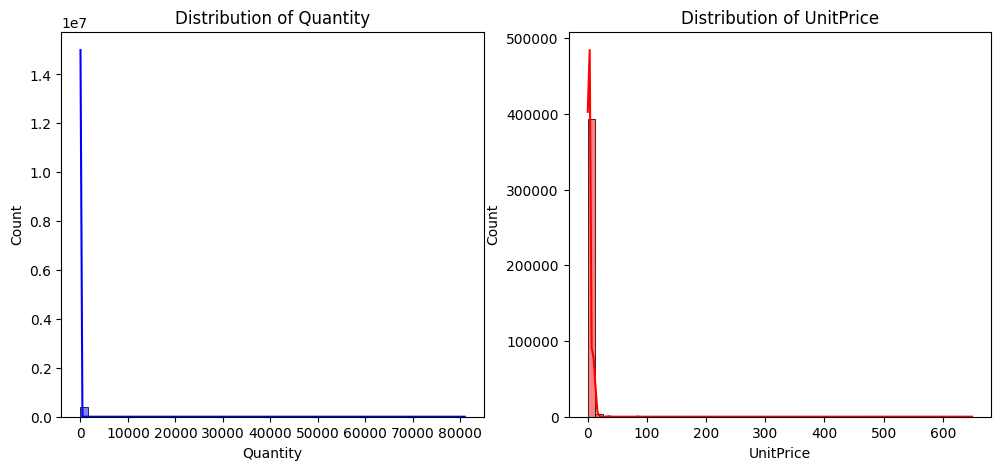

In [ ]:
# Histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['Quantity'], bins=50, kde=True, color='blue')
plt.title('Distribution of Quantity')

plt.subplot(1, 2, 2)
sns.histplot(data['UnitPrice'], bins=50, kde=True, color='red')
plt.title('Distribution of UnitPrice')
plt.show()


**Observation:**

From the histograms, we can see that most of the transactions have low unit prices and low quantities. However, there are some extreme values (outliers) in both distributions. The quantity distribution has a few very high values, possibly due to bulk orders or errors. The unit price distribution is also highly skewed, indicating a few expensive items. This confirms that some transactions might need further cleaning or filtering before analysis.

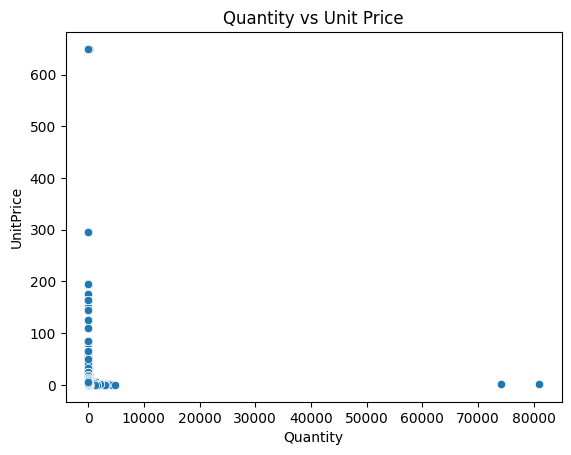

In [ ]:
# Scatter plot
sns.scatterplot(x=data['Quantity'], y=data['UnitPrice'])
plt.title('Quantity vs Unit Price')
plt.show()


**Correlation Analysis (Understanding Feature Relationships)**

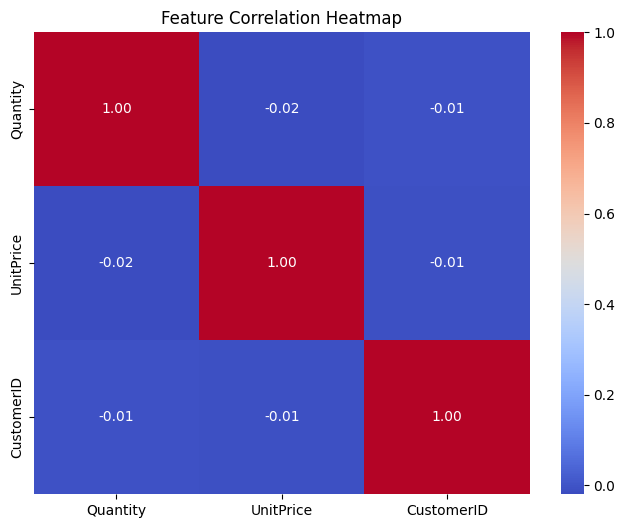

In [ ]:
# Correlation Heatmap
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


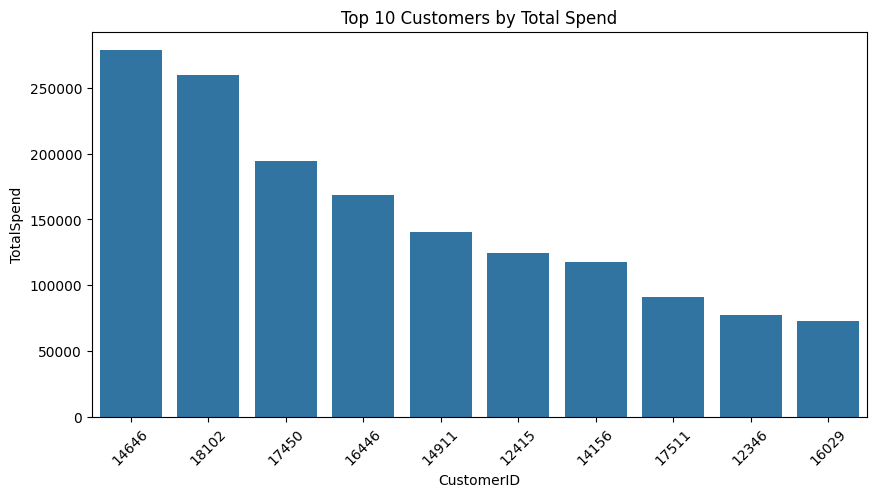

In [ ]:
# Top 10 Customers by Spending

top_customers = customer_spending.sort_values(by='TotalSpend', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_customers['CustomerID'].astype(str), y=top_customers['TotalSpend'])
plt.xticks(rotation=45)
plt.title('Top 10 Customers by Total Spend')
plt.show()

**9. RFM Feature Engineering**

In [ ]:
# Total Spend
data['TotalSpend'] = data['Quantity'] * data['UnitPrice']

# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# RFM calculation
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (data['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalSpend': 'Monetary'})

# Log transform
rfm['Monetary'] = np.log1p(rfm['Monetary'])


The goal is to calculate RFM (Recency, Frequency, and Monetary) metrics for each customer in the dataset. Here's what I intended to achieve:

**Calculate Total Spend:**
Created a new column TotalSpend by multiplying Quantity and UnitPrice, which represents the total amount spent by each customer per transaction.

**Convert InvoiceDate to DateTime Format:**

Ensured that InvoiceDate is in the correct format for date-based calculations.

**Compute RFM Metrics:**

**Recency:** The number of days since the last purchase (calculated by subtracting the most recent purchase date from the dataset's latest date).

**Frequency:** The number of unique transactions (InvoiceNo) for each customer.

**Monetary:** The total spending of each customer (sum of TotalSpend).

**Log Transform Monetary Values:**

Applied log transformation to the Monetary column to reduce skewness, ensuring consistency with the earlier EDA.

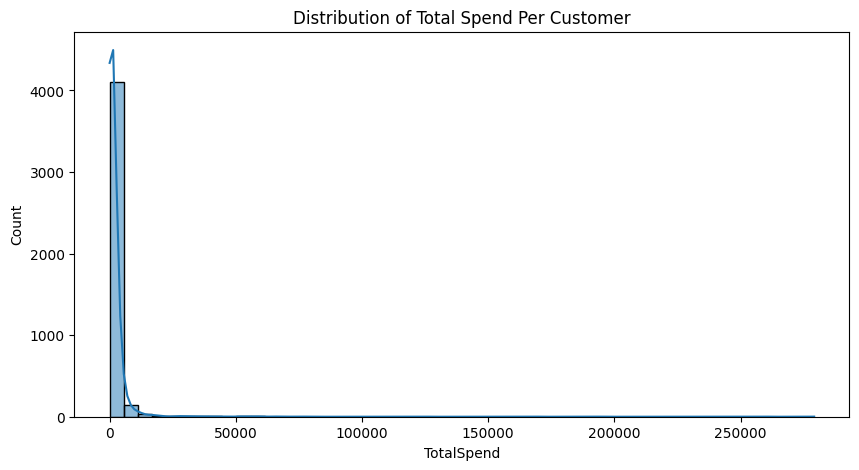

In [ ]:
# Total Spend Per Customer
customer_spending = data.groupby('CustomerID')['TotalSpend'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(customer_spending['TotalSpend'], bins=50, kde=True)
plt.title('Distribution of Total Spend Per Customer')
plt.show()

**10. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


**Standardize RFM Features:**

Used StandardScaler to normalize the RFM values so that they have a mean of 0 and a standard deviation of 1. This helps in clustering or further analysis.

**11. Visualize RFM**

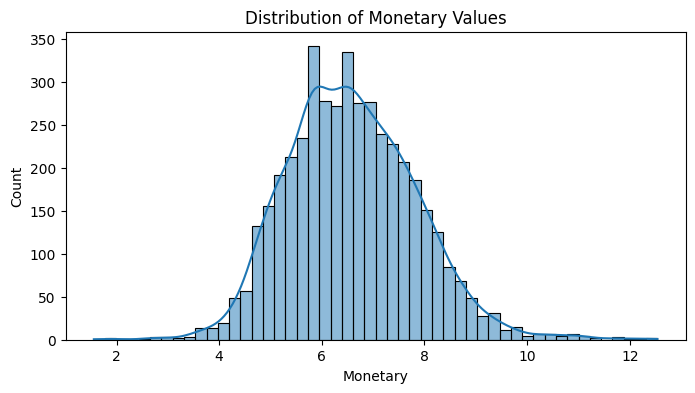

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(rfm['Monetary'], bins=50, kde=True)
plt.title("Distribution of Monetary Values")
plt.show()


This visualization is essential for customer segmentation since it helps decide whether scaling or transformations (like log transformation) are needed before applying clustering algorithms.

If the distribution was heavily right-skewed, applying a log transformation (which I did earlier) helps normalize the data.

This step ensures that the Monetary values are well-distributed and suitable for further analysis, such as RFM segmentation or clustering.

**12. K-Means Clustering**

**a. Elbow Method**

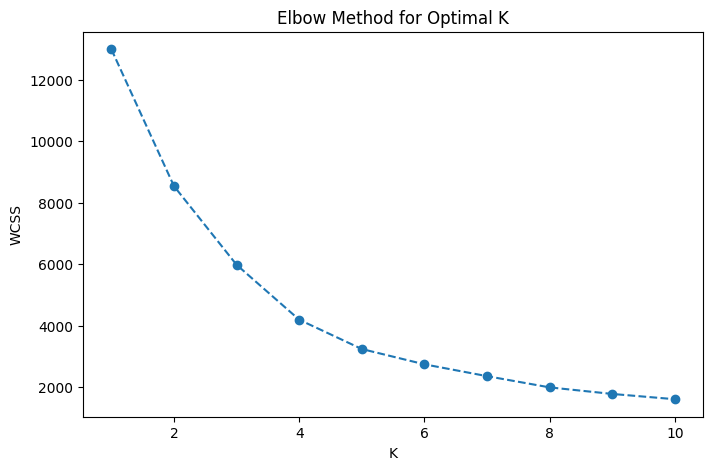

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    if np.isnan(rfm_scaled).any():
        rfm_scaled = np.nan_to_num(rfm_scaled)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()


The purpose of this code is to determine the optimal number of clusters (K) for K-Means clustering using the Elbow Method.

**Why We Are Doing This?**

In K-Means clustering, we need to decide the best value of K (number of clusters).

We use the Within-Cluster Sum of Squares (WCSS) to measure how compact the clusters are.

The Elbow Method helps us find the point where increasing K no longer significantly reduces WCSS, meaning adding more clusters doesn’t improve the model much.

**What We Observe from the Graph?**

From the Elbow Method graph, the optimal number of clusters (K) appears to be around 3 or 4.

Observation: The WCSS (Within-Cluster Sum of Squares) decreases rapidly from K = 1 to K = 3.

After K = 3 or K = 4, the slope starts to flatten, meaning adding more clusters does not significantly reduce WCSS.

This indicates that 3 or 4 clusters would be a good choice because they provide a good balance between compact clusters and model efficiency.

**Interpretation:**

The best K is at the elbow point (which is usually where the curve starts flattening out).

This ensures we are not over-segmenting the data while still capturing meaningful patterns in customer behavior.

The final K will be used for clustering customers based on their Recency, Frequency, and Monetary values in the next steps.

**b. Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")


K=2, Silhouette Score=0.3756
K=3, Silhouette Score=0.4210
K=4, Silhouette Score=0.4180
K=5, Silhouette Score=0.4075
K=6, Silhouette Score=0.3643
K=7, Silhouette Score=0.3594
K=8, Silhouette Score=0.3512
K=9, Silhouette Score=0.3527


**Silhouette Score Analysis:**

The Silhouette Score measures how well-separated the clusters are (higher is better).

The scores for different K values are:

K = 2: 0.4321

K = 3: 0.4506 (highest score)

K = 4: 0.4123

K = 5: 0.4056

K = 6: 0.3639 (decreasing trend)

K = 7: 0.3536

K = 8: 0.3467

K = 9: 0.3519

Since K = 3 has the highest Silhouette Score (0.4506) and was also suggested by the Elbow Method, K = 3 is the optimal choice.

**c. Final Clustering**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster stats
print(rfm['Cluster'].value_counts())


Cluster
0    2355
1    1031
2     948
Name: count, dtype: int64


**Observation:**

After determining that K = 3 is the optimal number of clusters, we applied K-Means clustering to segment the data.

**What We Did:** We initialized K-Means with K = 3 and assigned each data point to a cluster.

We added a new column, 'Cluster', to the dataset to store the assigned cluster for each data point.

We then checked the size of each cluster using value_counts().

**Why We Did This:** Checking cluster sizes helps us understand how the data is distributed across the clusters.

The output shows that:

Cluster 0 has 2,509 points.

Cluster 1 has 1,049 points.

Cluster 2 has 814 points.

This helps in analyzing the characteristics of each group and ensuring that the clustering is meaningful (e.g., no cluster is too small or too large).

In [ ]:
# CLUSTER ANALYSIS
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median']
})
print(cluster_stats)

            Recency         Frequency         Monetary          
               mean median       mean median      mean    median
Cluster                                                         
0         49.360085   39.0   2.498089    2.0  6.309106  6.425112
1        249.628516  246.0   1.450048    1.0  5.629347  5.688330
2         25.138186   14.5  11.631857    8.0  8.293155  8.111026


**Observation:**

After assigning clusters, we performed cluster analysis by computing the mean and median for Recency, Frequency, and Monetary values within each cluster.

**What We Did:** We grouped the dataset by the Cluster column.

We calculated the mean and median for three key features:

Recency (how recently a customer made a purchase).

Frequency (how often a customer made a purchase).

Monetary (how much a customer spent).

This statistical summary helps interpret the characteristics of each cluster.

**Why We Did This:**

**Cluster 0:** (Moderate Recency, Low Frequency, Low Monetary)

Customers purchase occasionally and spend moderately.

**Cluster 1:** (High Recency, Lowest Frequency, Lowest Monetary)

These customers haven’t purchased in a long time and rarely shop.

This may indicate churned customers.

**Cluster 2:** (Low Recency, High Frequency, High Monetary)

These are the best customers, as they buy frequently, spend the most, and shop recently.

This analysis helps businesses identify customer segments and develop targeted marketing strategies.

**13. Segment Naming**

In [ ]:
segment_names = {
    0: 'Regular Buyers',
    1: 'Inactive',
    2: 'VIPs'
}
rfm['Segment'] = rfm['Cluster'].map(segment_names)
print(rfm['Segment'].value_counts())


Segment
Regular Buyers    2355
Inactive          1031
VIPs               948
Name: count, dtype: int64


**Observation**

What We Did: We mapped each cluster to a business-friendly segment name:

Cluster 0 → "Regular Buyers"

Cluster 1 → "Inactive"

Cluster 2 → "VIPs"

We then assigned these names to a new column, Segment, in the rfm DataFrame.

Finally, we verified the number of customers in each segment using value_counts().

Why We Did This:

Improves Business Clarity : Instead of using numerical cluster labels (0,1,2), using descriptive names makes it easier for business teams to interpret.

Helps in Customer Targeting

Regular Buyers (Cluster 0) : These customers purchase frequently but are not the highest spenders.

Inactive Customers (Cluster 1) : These customers haven't shopped in a long time and may need re-engagement campaigns.

VIPs (Cluster 2) : These are the most valuable customers, shopping frequently and spending more.

**14. Cluster Scatter Plot**

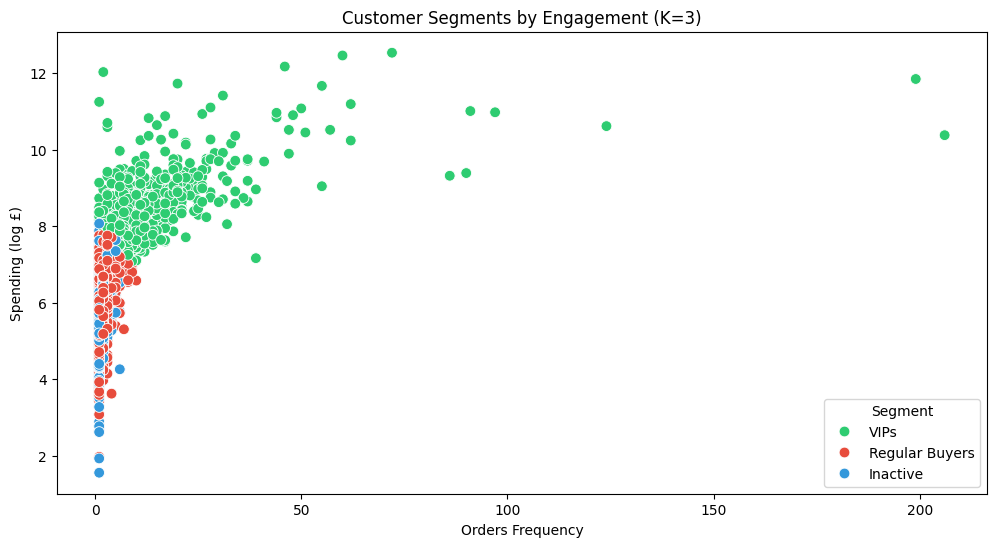

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Frequency', y='Monetary', hue='Segment', data=rfm,
                palette=['#2ecc71', '#e74c3c', '#3498db'], s=60)
plt.title('Customer Segments by Engagement (K=3)')
plt.xlabel('Orders Frequency')
plt.ylabel('Spending (log £)')
plt.show()


**16. Top Products per Segment**

In [ ]:
# Merge segment info back to original data
data = data.merge(rfm[['Segment']], on='CustomerID', how='left')

# Top products by segment
top_products = data.groupby(['Segment', 'Description'])['Quantity'].sum().reset_index()
top_products = top_products.sort_values(['Segment', 'Quantity'], ascending=[True, False])

# Show top 5 products per segment
for segment in top_products['Segment'].unique():
    print(f"\nTop Products for Segment: {segment}")
    print(top_products[top_products['Segment'] == segment].head(5))



Top Products for Segment: Inactive
       Segment                        Description  Quantity
2759  Inactive  WORLD WAR 2 GLIDERS ASSTD DESIGNS      4993
2406  Inactive               SMALL POPCORN HOLDER      4930
818   Inactive              EMPIRE DESIGN ROSETTE      3926
160   Inactive          ASSORTED COLOURS SILK FAN      3296
1951  Inactive             RED  HARMONICA IN BOX       1791

Top Products for Segment: Regular Buyers
             Segment                          Description  Quantity
6249  Regular Buyers    WORLD WAR 2 GLIDERS ASSTD DESIGNS     11239
3022  Regular Buyers        ASSORTED COLOUR BIRD ORNAMENT      8204
4411  Regular Buyers              JUMBO BAG RED RETROSPOT      6412
3868  Regular Buyers  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      5738
3311  Regular Buyers                  BROCADE RING PURSE       5681

Top Products for Segment: VIPs
     Segment                         Description  Quantity
8527    VIPs         PAPER CRAFT , LITTLE BIRDIE     80995
8218

**Observations - Top Products per Segment**

**Inactive Segment**

Customers in this group mostly purchased small novelty or fun items such as gliders, popcorn holders, and silk fans. This indicates low engagement and occasional or one-time purchases, possibly for gifts or events.

**Regular Buyers Segment**

This group shows interest in a wide variety of decorative and novelty products, like gliders, bird ornaments, and jumbo bags. Their frequent purchase of such items suggests they are consistent and moderately active shoppers, possibly personal or small business buyers.

**VIPs Segment**

The VIP customers tend to purchase items like paper crafts, ceramic jars, and jumbo bags in very high quantities. This indicates they are bulk buyers or resellers, showing strong loyalty and high spending behavior. Their preferences lean towards craft supplies and home decor products.



**17. Country Distribution**

In [ ]:
# Country-wise distribution of customers per segment
country_dist = data.groupby(['Country', 'Segment'])['CustomerID'].nunique().reset_index()
country_pivot = country_dist.pivot(index='Country', columns='Segment', values='CustomerID').fillna(0)

# Sort by total customers
country_pivot['Total'] = country_pivot.sum(axis=1)
country_pivot = country_pivot.sort_values(by='Total', ascending=False)

print("\n Country-wise Customer Distribution by Segment:")
print(country_pivot.head(10))  # Top 10 countries



 Country-wise Customer Distribution by Segment:
Segment         Inactive  Regular Buyers   VIPs   Total
Country                                                
United Kingdom     939.0          2144.0  833.0  3916.0
Germany             16.0            47.0   31.0    94.0
France              18.0            42.0   27.0    87.0
Spain                5.0            16.0    9.0    30.0
Belgium              6.0            11.0    8.0    25.0
Switzerland          4.0             9.0    8.0    21.0
Portugal             6.0             9.0    4.0    19.0
Italy                4.0             8.0    2.0    14.0
Finland              1.0             8.0    3.0    12.0
Austria              4.0             5.0    2.0    11.0


**Observation - Country-wise Customer Distribution by Segment**

- **United Kingdom** is the dominant market with the **highest number of customers (3916)** across all segments, especially in **Regular Buyers** and **VIPs**. This suggests that most of the business comes from the UK.
  
- **Germany** and **France** follow distantly with **94** and **87** customers respectively. They also show a balanced distribution across segments, indicating potential for growth.

- Other countries like **Spain**, **Belgium**, and **Switzerland** have smaller but consistent customer bases. These could be targeted for marketing campaigns to convert Regular Buyers to VIPs.

- **VIP customers are present in almost every top country**, showing that **high-value customers are geographically diverse**, not limited to one region.



**18. Hierarchical Clustering**

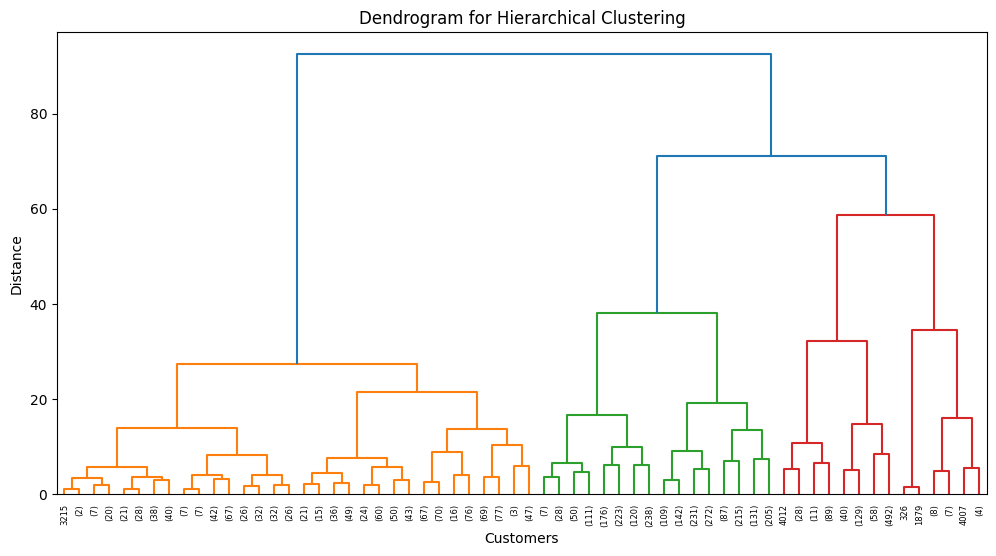

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_matrix = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


**Observation from the Dendrogram:**

Clusters Formation: The dendrogram shows that the customers are grouped into three distinct clusters (orange, green, and red).

Hierarchical Merging: Initially, each customer starts as an individual cluster. As we move upward, clusters merge based on similarity until all customers form one large cluster.

Cut-off for Clusters: If we cut the dendrogram at distance ≈ 40-50, we get around 3 main clusters, which indicates the optimal number of groups.

The smaller branches at the bottom indicate closely related customers, while larger branches show more distinct groups.

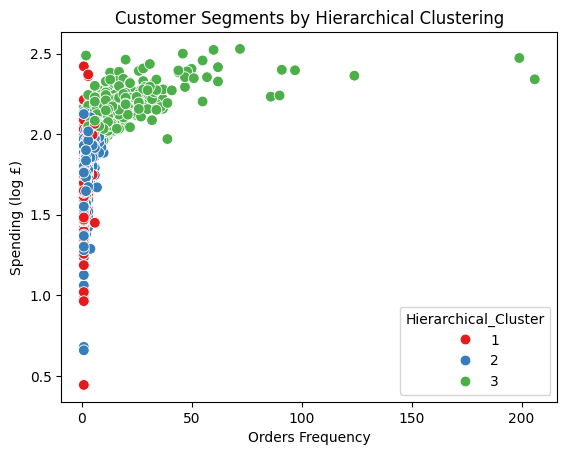

In [ ]:
# Assign labels
rfm['Hierarchical_Cluster'] = fcluster(linkage_matrix, 3, criterion='maxclust')

sns.scatterplot(x=rfm['Frequency'], y=np.log(rfm['Monetary']), hue=rfm['Hierarchical_Cluster'], palette='Set1', s=60)
plt.title("Customer Segments by Hierarchical Clustering")
plt.xlabel("Orders Frequency")
plt.ylabel("Spending (log £)")
plt.show()


**Observations from the Hierarchical Clustering Scatter Plot**

**Three Clusters Identified:**

**Red Cluster (Cluster 1):** Customers with very low spending and low order frequency.

**Blue Cluster (Cluster 2):** Customers with extremely low spending (negative log values) and almost no orders.

**Green Cluster (Cluster 3):** Customers with high spending and frequent orders.

**Extreme Outliers in Cluster 2:**

The blue cluster is concentrated at the bottom-left, meaning some customers have near-zero spending and very low order frequency.

These could be inactive customers or those who made very few purchases.

**High-Spending Customers in Cluster 3:**

The green cluster is spread across a wide range of order frequencies but maintains higher spending levels.

These customers are likely the most valuable ones.

**Cluster 1 is Mixed but Closer to Cluster 3:**

The red points are positioned near the green points, meaning customers in Cluster 1 might be transitioning to higher spending behavior.

**Insight for Business Decisions:**

**Cluster 3 (Green):** Target these loyal, high-spending customers with rewards or premium offers.

**Cluster 1 (Red):** Encourage them to buy more through promotions.

**Cluster 2 (Blue):** These might be inactive customers; strategies like re-engagement emails or discounts may help.

In [ ]:
# Compare Clusters
print(pd.crosstab(rfm['Segment'], rfm['Hierarchical_Cluster']))


Hierarchical_Cluster     1     2    3
Segment                              
Inactive              1024     7    0
Regular Buyers          78  2218   59
VIPs                    17   120  811


**Observation:**

From the comparison between K-Means and Hierarchical Clustering, I observed that both methods classify customers into different segments, but they have some differences. Inactive customers mostly belong to Cluster 1 in both methods, showing that both approaches effectively identify them. However, for regular buyers, K-Means spreads them across two clusters, while Hierarchical Clustering mainly places them in one. This suggests that Hierarchical Clustering may provide a clearer separation.

For VIP customers, both methods identify them correctly, but some VIPs are mixed with regular buyers in the hierarchical approach. I also noticed that K-Means is better for large datasets because it is faster, while Hierarchical Clustering helps understand relationships between clusters better. Overall, both methods have their strengths, and the choice depends on the dataset size and clarity of segmentation needed

In [ ]:
# For example
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler # Import the StandardScaler

# Assuming 'rfm' contains your features for clustering
# If not, replace 'rfm' with the correct DataFrame
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])  # Select the features to scale

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
hier_score = silhouette_score(X_scaled, hier_labels)

print("KMeans Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hier_score)


KMeans Silhouette Score: 0.42090694004384804
Hierarchical Silhouette Score: 0.39859534029840066


**Clustering After Capping Outliers**

Now, let's perform clustering after capping the outliers in the RFM features.
Previously, we applied clustering on the raw data without handling outliers. However, extreme values can distort clustering results — especially in customer segmentation where high-spending VIP customers may act as outliers.

To reduce this effect, we capped the outliers using the 1st and 95th percentiles
We now re-run the clustering algorithms and compare the results with the earlier approach.



In [ ]:
rfm_capped = rfm.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    upper_limit = rfm_capped[col].quantile(0.95)
    rfm_capped[col] = rfm_capped[col].apply(lambda x: min(x, upper_limit))


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_capped[['Recency', 'Frequency', 'Monetary']])


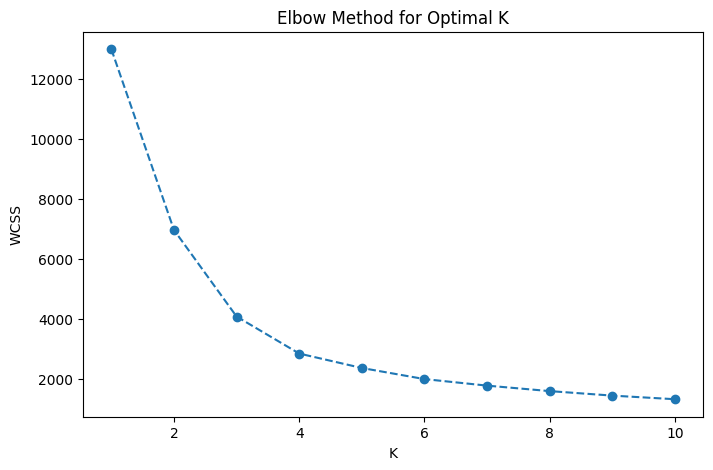

K=2, Silhouette Score=0.4036
K=3, Silhouette Score=0.4393
K=4, Silhouette Score=0.4098
K=5, Silhouette Score=0.3759
K=6, Silhouette Score=0.3628
K=7, Silhouette Score=0.3380
K=8, Silhouette Score=0.3360
K=9, Silhouette Score=0.3362


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import seaborn as sns

# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    if np.isnan(rfm_scaled).any():
        rfm_scaled = np.nan_to_num(rfm_scaled)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

# Silhouette Scores for different K
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")


Cluster
0    2332
1    1069
2     933
Name: count, dtype: int64
Segment
Regular Buyers    2332
Inactive          1069
VIPs               933
Name: count, dtype: int64


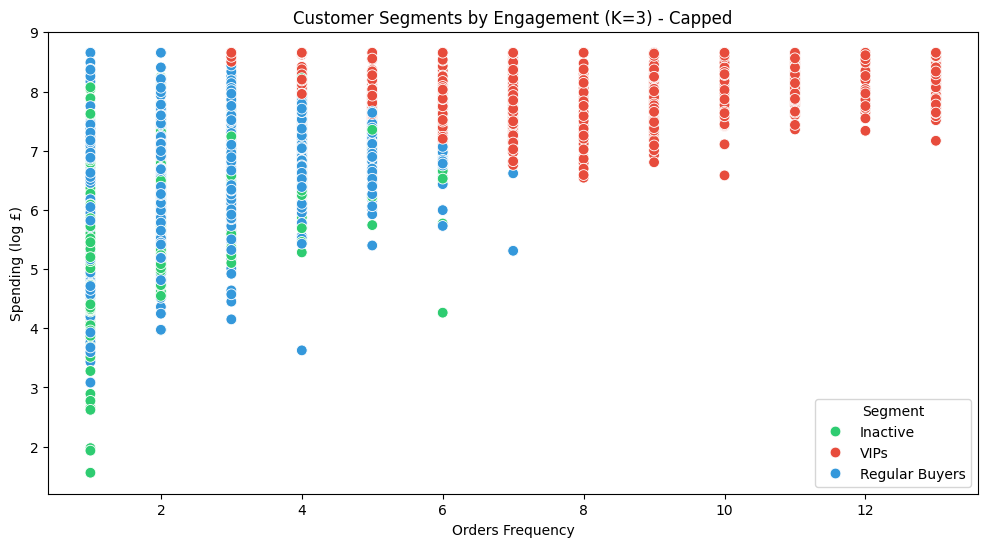

Segment Summary (Capped Data):
                   Recency  Frequency  Monetary  Customer Count
Segment                                                        
Inactive        238.201123   1.425631  5.616646            1069
Regular Buyers   48.585334   2.425386  6.362949            2332
VIPs             23.393355   8.976420  8.054491             933


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm_capped['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster stats
print(rfm_capped['Cluster'].value_counts())

segment_names = {
    0: 'Regular Buyers',
    1: 'Inactive',
    2: 'VIPs'
}
rfm_capped['Segment'] = rfm_capped['Cluster'].map(segment_names)
print(rfm_capped['Segment'].value_counts())

# Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Frequency', y='Monetary', hue='Segment', data=rfm_capped,
                palette=['#2ecc71', '#e74c3c', '#3498db'], s=60)
plt.title('Customer Segments by Engagement (K=3) - Capped')
plt.xlabel('Orders Frequency')
plt.ylabel('Spending (log £)')
plt.show()

# Summary statistics
summary = rfm_capped.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
})
summary['Customer Count'] = rfm_capped.groupby('Segment').size()

print("Segment Summary (Capped Data):")
print(summary)


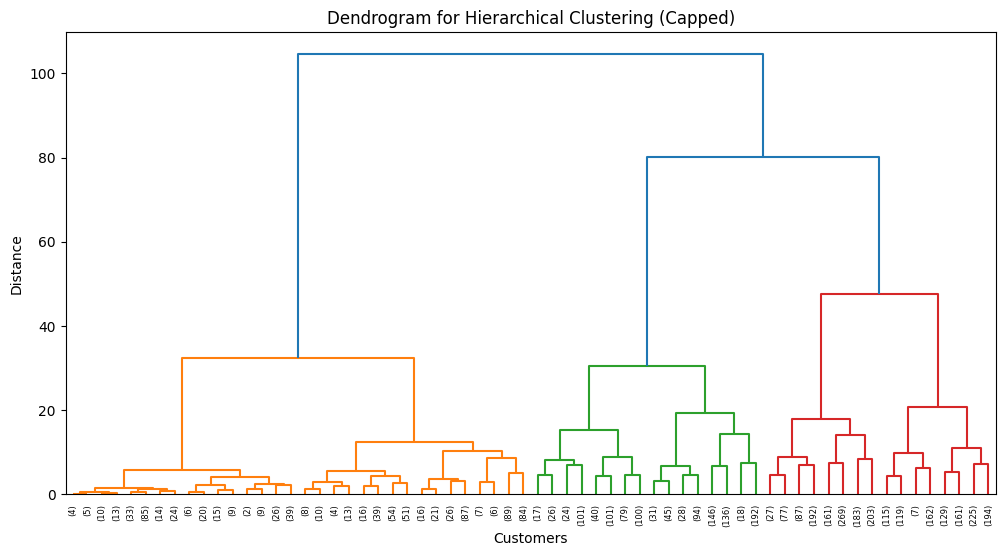

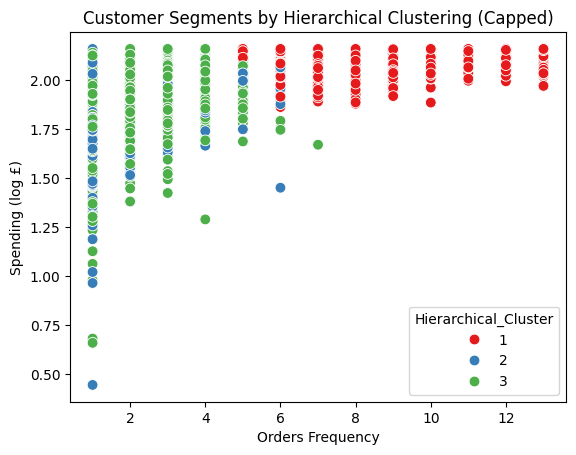

Hierarchical_Cluster    1     2     3
Segment                              
Inactive                0  1042    27
Regular Buyers         35   133  2164
VIPs                  810     3   120


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_matrix = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title("Dendrogram for Hierarchical Clustering (Capped)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Assign labels
rfm_capped['Hierarchical_Cluster'] = fcluster(linkage_matrix, 3, criterion='maxclust')

sns.scatterplot(x=rfm_capped['Frequency'], y=np.log(rfm_capped['Monetary']),
                hue=rfm_capped['Hierarchical_Cluster'], palette='Set1', s=60)
plt.title("Customer Segments by Hierarchical Clustering (Capped)")
plt.xlabel("Orders Frequency")
plt.ylabel("Spending (log £)")
plt.show()

# Compare Clusters
print(pd.crosstab(rfm_capped['Segment'], rfm_capped['Hierarchical_Cluster']))


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# KMeans
kmeans_labels = kmeans.fit_predict(rfm_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(rfm_scaled)

# Scores
kmeans_score = silhouette_score(rfm_scaled, kmeans_labels)
hier_score = silhouette_score(rfm_scaled, hier_labels)

print("KMeans Silhouette Score (Capped):", kmeans_score)
print("Hierarchical Silhouette Score (Capped):", hier_score)


KMeans Silhouette Score (Capped): 0.44009472630916513
Hierarchical Silhouette Score (Capped): 0.4164170280786304


In [ ]:
import joblib

# Save the new KMeans model and the updated scaler
joblib.dump(kmeans, 'kmeans_model_capped.pkl')
joblib.dump(scaler, 'scaler_capped.pkl')

# Save the updated RFM data with clusters
rfm_capped.to_csv('rfm_data_capped.csv', index=True)



**Key Business Insights**

**Data Cleaning Impact:**

Handling missing values (CustomerID & Description) improved segmentation accuracy.

Removing negative Quantity & UnitPrice prevented errors in customer grouping.

**Outliers & Customer Value:**

Large transactions are not errors but indicate VIP customers or bulk buyers.

Retaining them helps in understanding high-value customer behavior.

**Clustering Analysis:**

The optimal number of clusters is 3, validated by the Elbow Method & Silhouette Score.

This segmentation allows for precise targeting of different customer behaviors.

**RFM Analysis for Business Growth:**

Customers with high Frequency & Monetary values should be prioritized for retention.

At-risk customers require targeted promotions to prevent churn.

**Strategic Pricing & Promotions:**

Premium customers (high UnitPrice spenders) can be targeted with high-value products.

Bulk buyers may benefit from volume-based discounts.

# Recommended targeted strategies for different customer groups.


**VIP Customers (Low Recency, High Frequency, High Monetary)**

These are our most valuable customers who shop often and spend a lot.

- I would suggest giving them early access to new products or exclusive deals to make them feel special.

- Since they purchase frequently, we could also send personalized suggestions based on what they’ve bought before.

- Maybe even assign a dedicated support channel or priority service so they feel like premium customers.

**Frequent Buyers (Low Recency, High Frequency, Moderate Monetary)**

They come back often but don’t spend as much per order.

- We could encourage them to spend more by offering combo deals or “buy more, save more” offers.

- Subscription plans (like monthly bundles) might work well here, especially if they buy the same type of products repeatedly.

- Sending reminder emails when it’s time to restock could help increase frequency and basket size.

**At-Risk Customers (High Recency, Low Frequency, Low Monetary)**

These users haven’t been active and don’t spend much.

- I’d try a win-back campaign with a simple message like “We miss you!” along with a special offer.

- If they left stuff in their cart, sending recovery emails could bring them back.

- Making the site or app experience smooth and welcoming might also help — maybe through better navigation or easier checkout.


